In [2]:
import pandas as pd

from sembench.src.closed_model_stats import MMQA_STATS, MOVIE_STATS, ECOMM_STATS, WILDLIFE_STATS, CARS_STATS

In [3]:
bl_total_cost = 0
bs_total_cost = 0
hourly_rate = 0.18
CLOSED_COLNAME = "Avg. SemBench System with gemini-2.5-flash"
OPEN_COLNAME = "BlendSQL w/ local gemma-4-E4B-it-fp8"
all_model_avgs = []
for task, stat in [('mmqa', MMQA_STATS), ('movie', MOVIE_STATS), ('ecomm', ECOMM_STATS), ('wildlife', WILDLIFE_STATS), ('cars', CARS_STATS)]:
    bl_agg = (
            pd.DataFrame(stat).groupby('query')
            .agg(bl_latency=('latency', 'mean'),
                 bl_quality=('quality', 'mean'),
                 bl_cost=('cost', 'mean'))
            .reset_index()
            .rename(columns={'query': 'query_name'})
        )
    bl_agg['bl_cost_scaled'] = bl_agg['bl_cost'] * 5
    bl_total_cost += bl_agg['bl_cost_scaled'].sum()
    all_model_avgs.append(
        {
            "task": task,
            "latency": bl_agg['bl_latency'].mean(),
            "quality": bl_agg['bl_quality'].mean(),
            "cost": bl_agg['bl_cost_scaled'].mean(),
            "model": CLOSED_COLNAME,
        }
    )

    df_bs = pd.read_csv(f"../results/blendsql_comparison_to_closed/{task}/gemma_e4b/all_results_with_runs.csv")
    df_bs['cost'] = df_bs['latency'] * hourly_rate / 3600.0
    bs_agg = (
        df_bs.groupby('query_name')
        .agg(bs_latency=('latency', 'mean'),
             bs_quality=('quality', 'mean'),
             bs_cost=('cost', 'mean'))
        .reset_index()
    )
    bs_agg['bs_cost_scaled'] = bs_agg['bs_cost'] * 5
    bs_total_cost += bs_agg['bs_cost_scaled'].sum()
    all_model_avgs.append(
        {
            "task": task,
            "latency": bs_agg['bs_latency'].mean(),
            "quality": bs_agg['bs_quality'].mean(),
            "cost": bs_agg['bs_cost_scaled'].mean(),
            "model": OPEN_COLNAME,
        }
    )

df = pd.DataFrame(all_model_avgs)
df = df.replace(to_replace={
        CLOSED_COLNAME: f"{CLOSED_COLNAME} (total cost: ${round(bl_total_cost, 2)})",
        OPEN_COLNAME: f"{OPEN_COLNAME} (total cost: ${round(bs_total_cost, 2)})",
    }
)

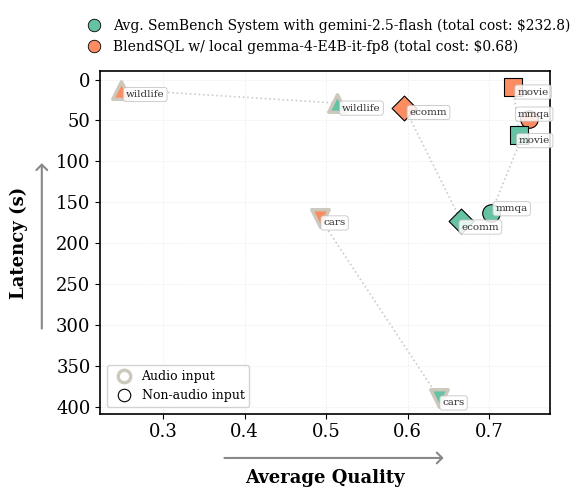

In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from adjustText import adjust_text

AUDIO_TASKS = {"cars", "wildlife"}

# ── Visual mappings ─────────────────────────────────────────────────────────
unique_models = df["model"].unique()
unique_tasks = df["task"].unique()

# Colors → models
palette = sns.color_palette("Set2", len(unique_models))
color_map = dict(zip(unique_models, palette))

# Marker shapes → tasks
marker_pool = ["o", "s", "D", "^", "v", "P", "X", "*", "h"]
marker_map = dict(zip(unique_tasks, marker_pool[: len(unique_tasks)]))

# ── Plot ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "font.size": 13,
    "axes.linewidth": 1.2,
})

fig, ax = plt.subplots(figsize=(6, 6))

texts = []
bbox_props = dict(
    boxstyle="round,pad=0.25",
    facecolor="white",
    edgecolor="#bbb",
    alpha=0.85,
    linewidth=0.6,
)

for task in unique_tasks:
    task_df = df[df["task"] == task]
    if len(task_df) == 2:
        rows = task_df[["quality", "latency"]].values
        ax.plot(
            rows[:, 0], rows[:, 1],
            color="#ccc", linestyle=":", linewidth=1.2, zorder=1,
        )

AUDIO_EDGE_COLOR = "#ccc8bc"
AUDIO_EDGE_WIDTH = 2.4
STD_EDGE_COLOR = "black"
STD_EDGE_WIDTH = 0.8

for _, row in df.iterrows():
    c = color_map[row["model"]]
    m = marker_map[row["task"]]
    is_audio = row["task"] in AUDIO_TASKS

    ax.scatter(
        row["quality"], row["latency"],
        color=c, marker=m, s=160,
        edgecolor=AUDIO_EDGE_COLOR if is_audio else STD_EDGE_COLOR,
        linewidth=AUDIO_EDGE_WIDTH if is_audio else STD_EDGE_WIDTH,
        zorder=5,
    )

    texts.append(
        ax.text(
            row["quality"], row["latency"], row["task"],
            fontsize=7.5, color="#333",
            bbox=bbox_props,
            zorder=6,
        )
    )

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.6),
            force_text=(0.8, 0.8), force_points=(0.5, 0.5),
            expand=(1.3, 1.5))

# ── Axes formatting ─────────────────────────────────────────────────────────
ax.set_xlabel("Average Quality", fontsize=13, fontweight="bold", labelpad=20)
ax.set_ylabel("Latency (s)", fontsize=13, fontweight="bold", labelpad=20)
ax.invert_yaxis()
ax.grid(True, alpha=0.2, linestyle="--")
ax.set_axisbelow(True)

# ── "Good direction" arrows outside axis labels ────────────────────────────
arrow_color = "#888"
arrow_props = dict(
    arrowstyle="->,head_width=0.3,head_length=0.3",
    color=arrow_color,
    lw=1.5,
)

# X-axis: arrow pointing right (higher quality = better)
fig.canvas.draw()  # force layout so transforms are valid
ax.annotate(
    "", xy=(0.77, -0.13), xytext=(0.27, -0.13),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=arrow_props,
)

# Y-axis: arrow pointing up (lower latency = better, but axis is inverted)
ax.annotate(
    "", xy=(-0.13, 0.74), xytext=(-0.13, 0.24),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=arrow_props,
)

# ── Legend: audio vs non-audio — pinned first via add_artist ──────────────
audio_handle = mlines.Line2D(
    [], [], color="white", marker="o", linestyle="",
    markersize=9,
    markeredgecolor=AUDIO_EDGE_COLOR, markeredgewidth=AUDIO_EDGE_WIDTH,
    label="Audio input",
)
std_handle = mlines.Line2D(
    [], [], color="white", marker="o", linestyle="",
    markersize=9,
    markeredgecolor=STD_EDGE_COLOR, markeredgewidth=STD_EDGE_WIDTH,
    label="Non-audio input",
)

audio_leg = ax.legend(
    handles=[audio_handle, std_handle],
    loc="lower left",
    fontsize=9, frameon=True, framealpha=0.85,
    edgecolor="#ccc", handletextpad=0.4,
)
ax.add_artist(audio_leg)

# ── Legend: models (color) — created last so it becomes the active legend ──
model_handles = [
    mlines.Line2D([], [], color=color_map[m], marker="o", linestyle="",
                  markersize=9, markeredgecolor="black", markeredgewidth=0.6,
                  label=m)
    for m in unique_models
]

ax.legend(
    handles=model_handles,
    loc="upper center",
    ncol=1,
    fontsize=10, frameon=False, fancybox=True,
    handletextpad=0.4, columnspacing=1.2,
    borderpad=0.6, shadow=False,
    edgecolor="#ccc", bbox_to_anchor=(0.5, 1.2)
)

fig.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig('../img/overall_summary.pdf', bbox_inches='tight')
plt.show()